# 03 — Yards Gained Model Eval (quick plots)

Holdout predictions from the active experiment under `artifacts/modeling/experiments/`. Messy on purpose — just to eyeball model behavior.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve() if (Path.cwd().name == "notebooks") else Path(".").resolve()

from src.utils.experiments import resolve_task_artifacts_dir

YARDS_DIR = resolve_task_artifacts_dir("yards_gained")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

preds = pd.read_parquet(YARDS_DIR / "test_predictions.parquet")
holdout = pd.read_csv(YARDS_DIR / "holdout_results.csv")
comparison = pd.read_csv(YARDS_DIR / "model_comparison.csv")
print(f"yards artifacts: {YARDS_DIR}")

BEST = "xgboost"
y_true = preds["y_true"].values
y_pred = preds[f"y_pred_{BEST}"].values
residual = y_true - y_pred

print(f"holdout rows: {len(preds):,}")
print(holdout.to_string(index=False))

holdout rows: 55,258
        model     rmse      mae        r2  median_absolute_error
     baseline 8.656842 5.846441 -0.000009               5.465086
random_forest 8.646757 5.826273  0.002319               4.398836
      xgboost 8.558399 5.726750  0.022605               4.481659


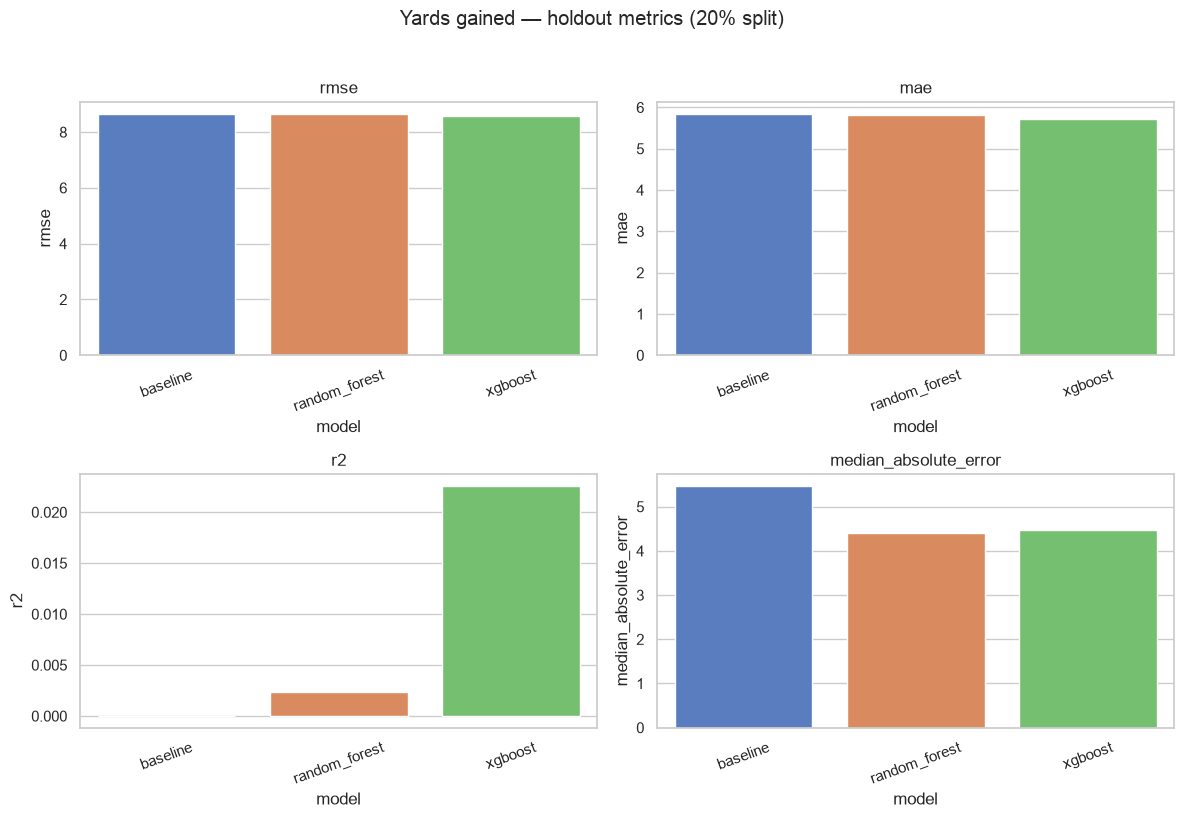

In [2]:
# primary metric comparison across models
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=holdout, x="model", y="rmse", ax=ax, palette="muted")
ax.set_title("rmse")
ax.tick_params(axis="x", rotation=20)
fig.suptitle("Yards gained — holdout RMSE (20% split)", y=1.02)
plt.tight_layout()
plt.show()

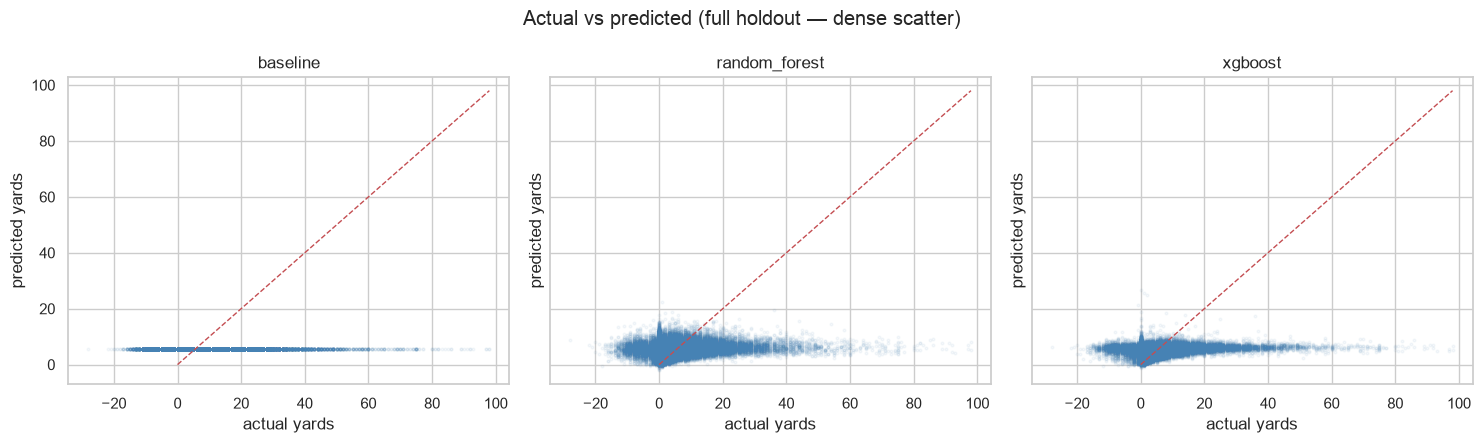

In [3]:
# actual vs predicted — all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, model in zip(axes, ["baseline", "random_forest", "xgboost"]):
    yt = preds["y_true"]
    yp = preds[f"y_pred_{model}"]
    ax.scatter(yt, yp, alpha=0.05, s=4, c="steelblue")
    lim = max(yt.max(), yp.max())
    ax.plot([0, lim], [0, lim], "r--", lw=1)
    ax.set_title(model)
    ax.set_xlabel("actual yards")
    ax.set_ylabel("predicted yards")

fig.suptitle("Actual vs predicted (full holdout — dense scatter)")
plt.tight_layout()
plt.show()

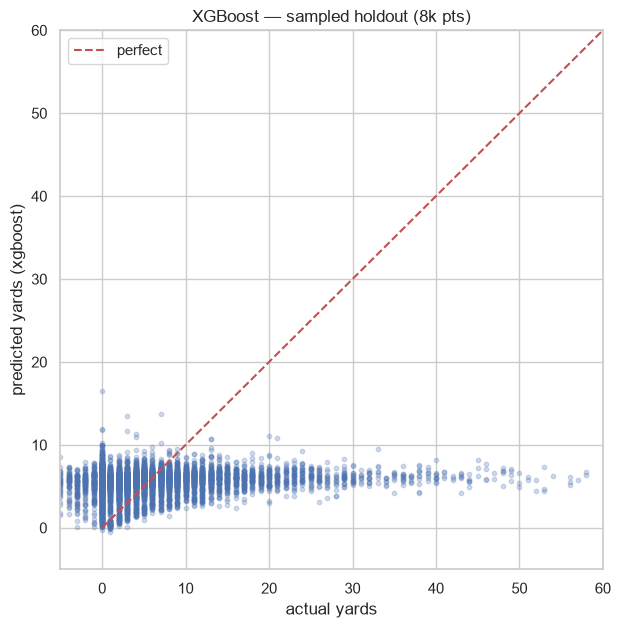

In [4]:
# zoomed scatter for xgboost (sample so it's readable)
sample = preds.sample(n=min(8000, len(preds)), random_state=42)
plt.figure(figsize=(7, 7))
plt.scatter(sample["y_true"], sample[f"y_pred_{BEST}"], alpha=0.25, s=10)
plt.plot([0, 80], [0, 80], "r--", label="perfect")
plt.xlim(-5, 60)
plt.ylim(-5, 60)
plt.xlabel("actual yards")
plt.ylabel(f"predicted yards ({BEST})")
plt.title("XGBoost — sampled holdout (8k pts)")
plt.legend()
plt.show()

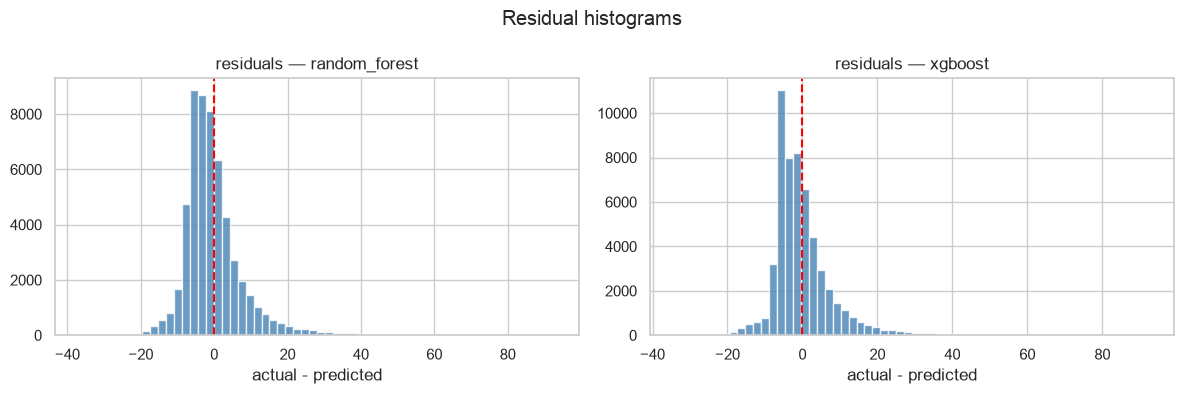

In [5]:
# residual distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model, ax in zip(["random_forest", "xgboost"], axes):
    resid = preds["y_true"] - preds[f"y_pred_{model}"]
    ax.hist(resid, bins=60, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(0, color="red", ls="--")
    ax.set_title(f"residuals — {model}")
    ax.set_xlabel("actual - predicted")

fig.suptitle("Residual histograms")
plt.tight_layout()
plt.show()

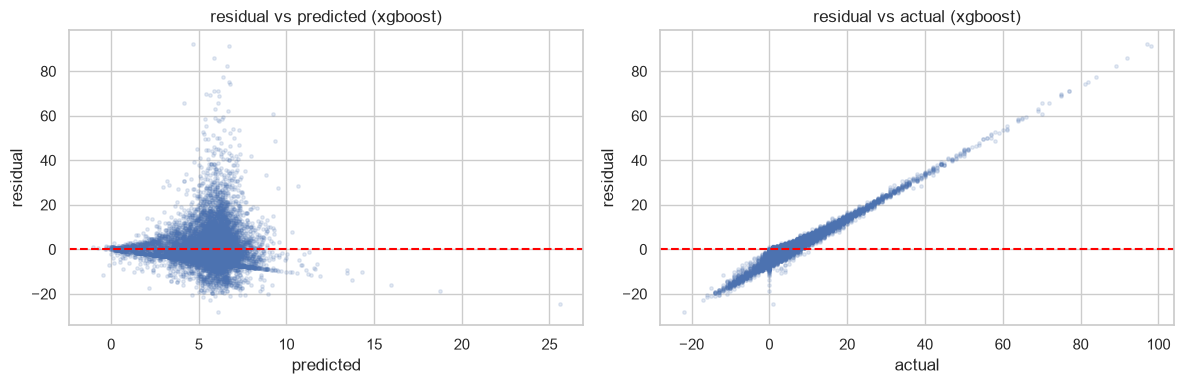

In [6]:
# residual vs predicted + residual vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = preds.sample(n=min(12000, len(preds)), random_state=7)
r = sample["y_true"] - sample[f"y_pred_{BEST}"]

axes[0].scatter(sample[f"y_pred_{BEST}"], r, alpha=0.15, s=6)
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("residual")
axes[0].set_title(f"residual vs predicted ({BEST})")

axes[1].scatter(sample["y_true"], r, alpha=0.15, s=6)
axes[1].axhline(0, color="red", ls="--")
axes[1].set_xlabel("actual")
axes[1].set_ylabel("residual")
axes[1].set_title(f"residual vs actual ({BEST})")

plt.tight_layout()
plt.show()

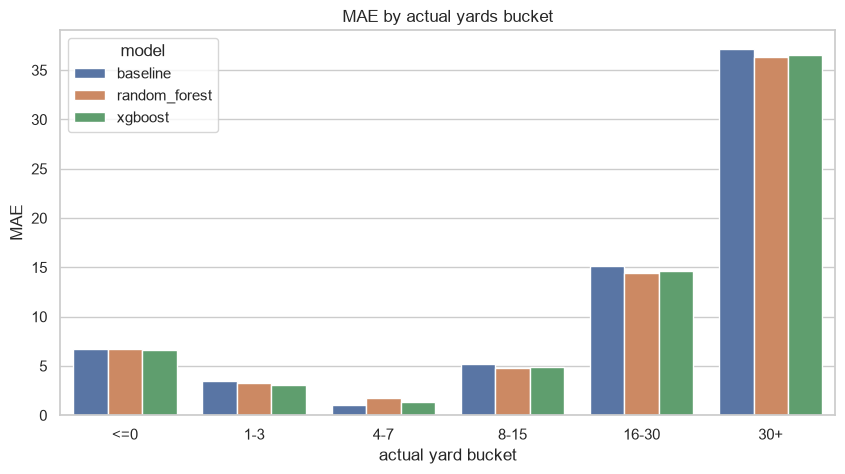

In [7]:
# MAE by actual-yard bucket
bins = [-20, 0, 3, 7, 15, 30, 100]
labels = ["<=0", "1-3", "4-7", "8-15", "16-30", "30+"]
tmp = preds.copy()
tmp["yard_bucket"] = pd.cut(tmp["y_true"], bins=bins, labels=labels)

mae_rows = []
for model in ["baseline", "random_forest", "xgboost"]:
    err = (tmp["y_true"] - tmp[f"y_pred_{model}"]).abs()
    mae_by = err.groupby(tmp["yard_bucket"], observed=True).mean()
    for bucket, mae in mae_by.items():
        mae_rows.append({"model": model, "yard_bucket": bucket, "mae": mae})

mae_df = pd.DataFrame(mae_rows)
plt.figure(figsize=(10, 5))
sns.barplot(data=mae_df, x="yard_bucket", y="mae", hue="model")
plt.title("MAE by actual yards bucket")
plt.xlabel("actual yard bucket")
plt.ylabel("MAE")
plt.legend(title="model")
plt.show()

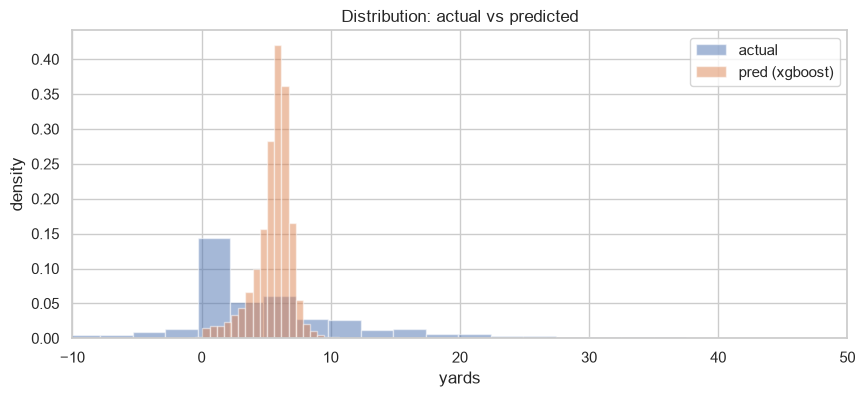

In [8]:
# predicted distribution vs actual
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_true, bins=50, alpha=0.5, label="actual", density=True)
ax.hist(y_pred, bins=50, alpha=0.5, label=f"pred ({BEST})", density=True)
ax.set_xlim(-10, 50)
ax.set_xlabel("yards")
ax.set_ylabel("density")
ax.set_title("Distribution: actual vs predicted")
ax.legend()
plt.show()

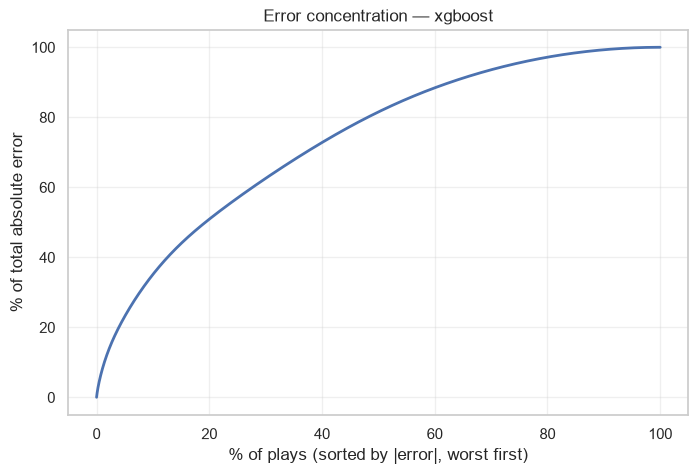

worst 5% of plays account for 23.1% of total |error|
worst 10% of plays account for 35.1% of total |error|
worst 20% of plays account for 50.9% of total |error|


In [9]:
# cumulative abs error — how much of total error comes from big misses?
abs_err = np.abs(residual)
sorted_err = np.sort(abs_err)[::-1]
cum_share = np.cumsum(sorted_err) / sorted_err.sum()
pct_plays = np.arange(1, len(sorted_err) + 1) / len(sorted_err) * 100

plt.figure(figsize=(8, 5))
plt.plot(pct_plays, cum_share * 100, lw=2)
plt.xlabel("% of plays (sorted by |error|, worst first)")
plt.ylabel("% of total absolute error")
plt.title(f"Error concentration — {BEST}")
plt.grid(True, alpha=0.3)
plt.show()

# rough headline numbers
for pct in [5, 10, 20]:
    n = int(len(sorted_err) * pct / 100)
    share = sorted_err[:n].sum() / sorted_err.sum() * 100
    print(f"worst {pct}% of plays account for {share:.1f}% of total |error|")